In [1]:
import glob, os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

paths = glob.glob("/kaggle/input/**/*.png", recursive=True)
print("Fichiers trouvés :", len(paths))

# Le dataset contient parfois 2 copies identiques : on garde une seule version de chaque image
uniq = {}
for p in paths:
    key = p.split("leapGestRecog/")[-1]
    uniq.setdefault(key, p)
paths = sorted(uniq.values())

df = pd.DataFrame({"path": paths})
df["subject"] = df["path"].apply(lambda p: p.split("/")[-3])
df["gesture"] = df["path"].apply(lambda p: p.split("/")[-2][3:])

print("Images uniques :", len(df))
print("Sujets :", sorted(df["subject"].unique()))
print(df["gesture"].value_counts())

Fichiers trouvés : 40000
Images uniques : 20000
Sujets : ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09']
gesture
palm          2000
l             2000
fist          2000
fist_moved    2000
thumb         2000
index         2000
ok            2000
palm_moved    2000
c             2000
down          2000
Name: count, dtype: int64


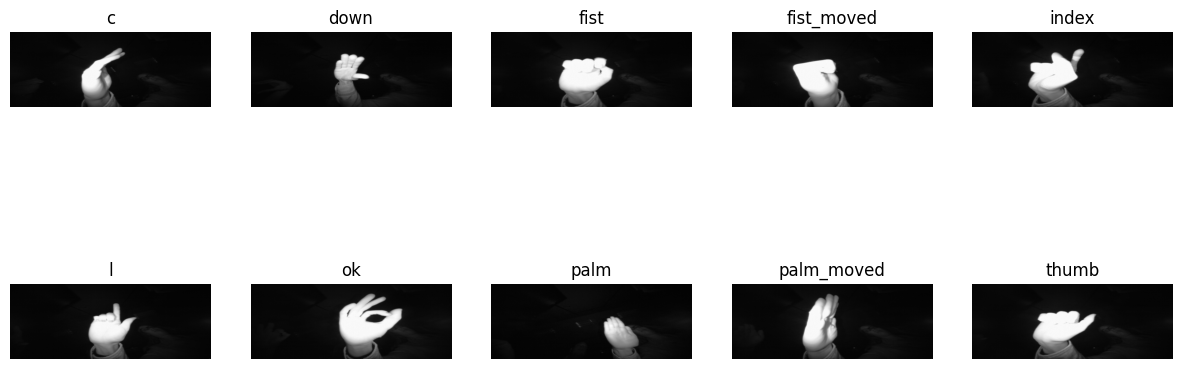

In [2]:
gestures = sorted(df["gesture"].unique())

plt.figure(figsize=(15, 6))
for i, g in enumerate(gestures):
    p = df[df["gesture"] == g]["path"].iloc[0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(Image.open(p), cmap="gray")
    plt.title(g)
    plt.axis("off")
plt.show()

In [3]:
import tensorflow as tf

IMG = 160
classes = sorted(df["gesture"].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
df["label"] = df["gesture"].map(class_to_idx)

train_df = df[df["subject"].isin(["00", "01", "02", "03", "04", "05", "06"])]
val_df   = df[df["subject"] == "07"]
test_df  = df[df["subject"].isin(["08", "09"])]
print("Train :", len(train_df), "| Val :", len(val_df), "| Test :", len(test_df))

def load_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMG, IMG))
    return img, label

def make_ds(d, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((d["path"].values, d["label"].values))
    if shuffle:
        ds = ds.shuffle(len(d), seed=42)
    return ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE).batch(64).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_df, shuffle=True)
val_ds   = make_ds(val_df)
test_ds  = make_ds(test_df)

Train : 14000 | Val : 2000 | Test : 4000


I0000 00:00:1790680692.415330      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790680692.418527      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(IMG, IMG, 3))
base.trainable = False   # on garde les connaissances de MobileNetV2

model = models.Sequential([
    layers.Input((IMG, IMG, 3)),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.Rescaling(1 / 127.5, offset=-1),
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(classes), activation="softmax"),
])

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history = model.fit(train_ds, validation_data=val_ds, epochs=5)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 37s 126ms/step - accuracy: 0.8880 - loss: 0.4041 - val_accuracy: 0.8570 - val_loss: 0.4517
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.9924 - loss: 0.0576 - val_accuracy: 0.8650 - val_loss: 0.3984
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - accuracy: 0.9958 - loss: 0.0326 - val_accuracy: 0.8725 - val_loss: 0.3526
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.9966 - loss: 0.0227 - val_accuracy: 0.8625 - val_loss: 0.4081
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.9977 - loss: 0.0170 - val_accuracy: 0.8790 - val_loss: 0.3733


In [5]:
base.trainable = True
for layer in base.layers[:100]:          # on garde les 100 premières couches gelées
    layer.trainable = False
for layer in base.layers:                # les BatchNorm restent figées (plus stable)
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

early = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3,
                                         restore_best_weights=True)

history_ft = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[early])

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 29s 95ms/step - accuracy: 0.9981 - loss: 0.0068 - val_accuracy: 0.9145 - val_loss: 0.2313
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - accuracy: 0.9989 - loss: 0.0046 - val_accuracy: 0.8995 - val_loss: 0.2932
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - accuracy: 0.9994 - loss: 0.0020 - val_accuracy: 0.9215 - val_loss: 0.2280
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 87ms/step - accuracy: 0.9992 - loss: 0.0027 - val_accuracy: 0.9145 - val_loss: 0.2214
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 87ms/step - accuracy: 0.9999 - loss: 7.9451e-04 - val_accuracy: 0.9025 - val_loss: 0.3014
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - accuracy: 1.0000 - loss: 2.4326e-04 - val_accuracy: 0.9395 - val_loss: 0.2710
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - accuracy: 0.9999 - loss: 8.0474e-04 - val_accuracy: 0.9370 - val_loss: 0.2674
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - accuracy: 0.9993 - los

Précision sur le test (personnes 08 et 09) : 0.942
              precision    recall  f1-score   support

           c       1.00      0.96      0.98       400
        down       1.00      1.00      1.00       400
        fist       1.00      0.73      0.85       400
  fist_moved       0.87      1.00      0.93       400
       index       1.00      1.00      1.00       400
           l       0.88      0.86      0.87       400
          ok       1.00      0.88      0.94       400
        palm       0.89      0.97      0.93       400
  palm_moved       1.00      1.00      1.00       400
       thumb       0.83      1.00      0.91       400

    accuracy                           0.94      4000
   macro avg       0.95      0.94      0.94      4000
weighted avg       0.95      0.94      0.94      4000



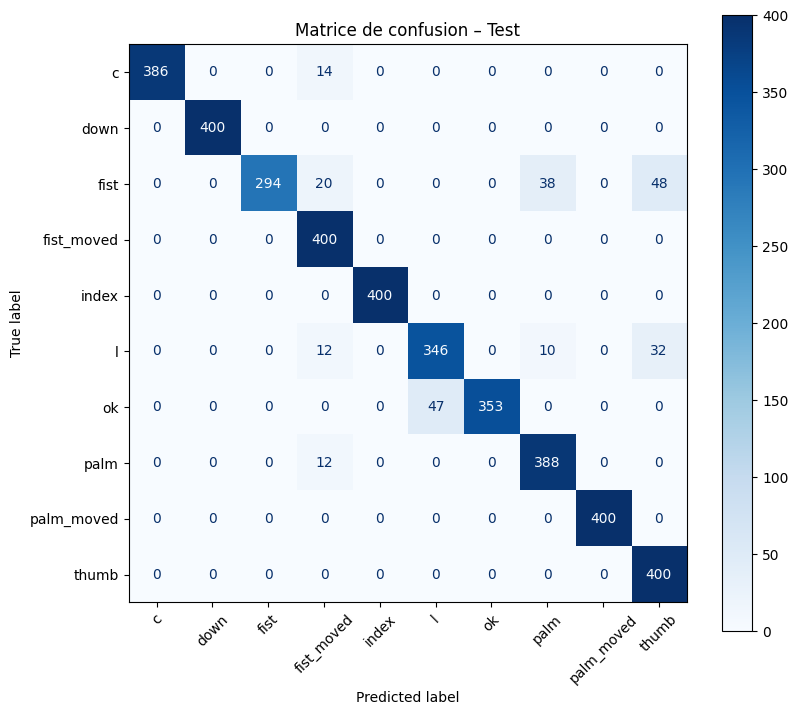

In [6]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Précision sur le test (personnes 08 et 09) : {test_acc:.3f}")

y_true = test_df["label"].values
y_pred = model.predict(test_ds, verbose=0).argmax(axis=1)

print(classification_report(y_true, y_pred, target_names=classes))

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=classes,
                                        xticks_rotation=45, cmap="Blues", ax=ax)
plt.title("Matrice de confusion – Test")
plt.show()

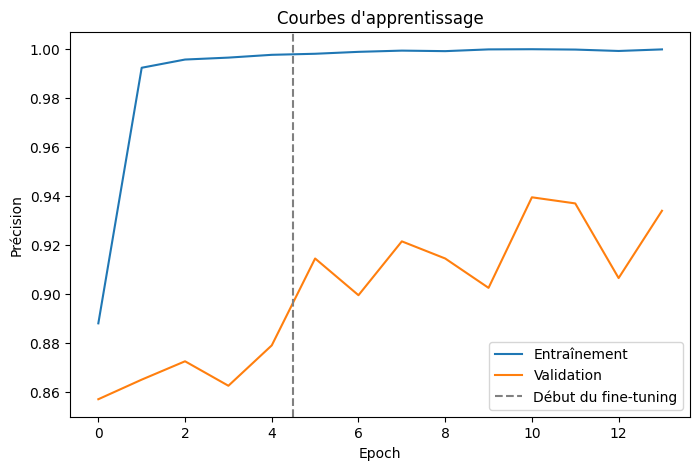

In [7]:
acc = history.history["accuracy"] + history_ft.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_ft.history["val_accuracy"]

plt.figure(figsize=(8, 5))
plt.plot(acc, label="Entraînement")
plt.plot(val_acc, label="Validation")
plt.axvline(x=len(history.history["accuracy"]) - 0.5, color="gray", linestyle="--", label="Début du fine-tuning")
plt.xlabel("Epoch")
plt.ylabel("Précision")
plt.title("Courbes d'apprentissage")
plt.legend()
plt.show()

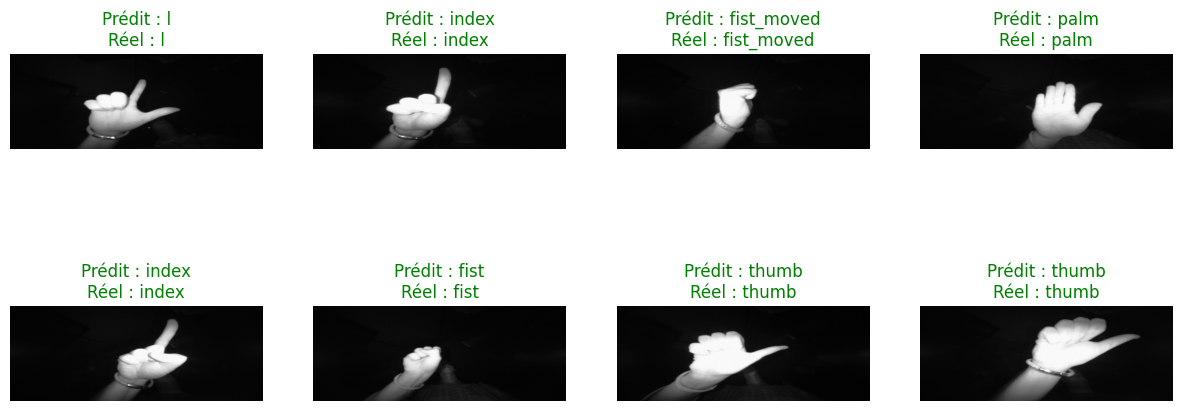

In [8]:
sample = test_df.sample(8, random_state=1)
imgs = np.stack([load_img(p, 0)[0].numpy() for p in sample["path"]])
preds = model.predict(imgs, verbose=0).argmax(axis=1)

plt.figure(figsize=(15, 6))
for i, (p, true_lab, pred) in enumerate(zip(sample["path"], sample["label"], preds)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(Image.open(p), cmap="gray")
    ok = pred == true_lab
    plt.title(f"Prédit : {classes[pred]}\nRéel : {classes[true_lab]}", color="green" if ok else "red")
    plt.axis("off")
plt.show()

In [9]:
model.save("hand_gesture_mobilenetv2.keras")
print("Modèle sauvegardé !")

Modèle sauvegardé !


## Conclusion
- Objectif : reconnaître 10 gestes de la main à partir d'images infrarouges (LeapGestRecog, 20 000 images, 10 personnes)
- Modèle : **CNN MobileNetV2 pré-entraîné (transfer learning)** + fine-tuning des dernières couches
- Évaluation rigoureuse : séparation **par personne** (entraînement 00–06, validation 07, test 08–09)
- Résultat sur des personnes jamais vues : **précision = 94,2 %**
- Gestes parfaitement reconnus : down, index, palm_moved (100 %)
- Principale confusion : fist ↔ fist_moved / thumb (gestes à main fermée)
- Amélioration possible : entraîner sur plus de personnes, plus d'augmentation de données